<a href="https://colab.research.google.com/github/gnanikaomkarini/hangman/blob/main/AI_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['Hours_Studied', 'Marks'], dtype='object')
Slope before regression: 0


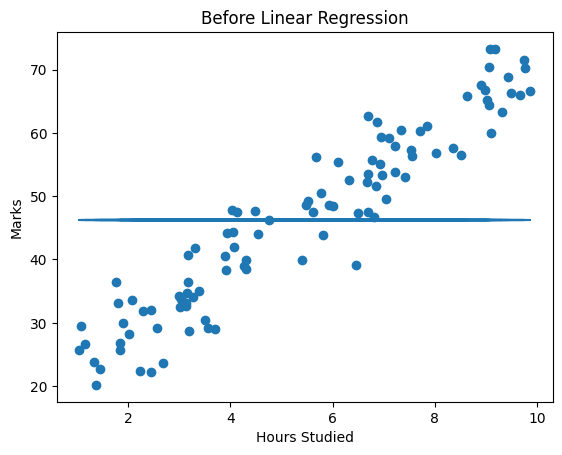

Slope after regression: 5.228


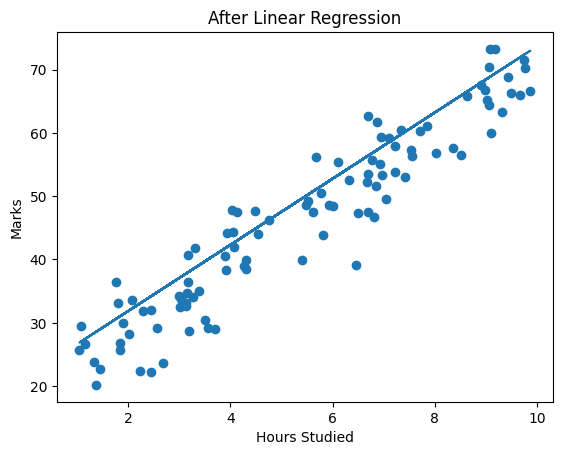

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_graph(X, Y, L, t):
    plt.scatter(X, Y)
    plt.plot(X, L)
    plt.xlabel("Hours Studied")
    plt.ylabel("Marks")
    plt.title(t)
    plt.show()

data = pd.read_csv("/content/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
print(data.columns)

X = data["Hours_Studied"].values
Y = data["Marks"].values

m1, c1 = 0, Y[0]
print("Slope before regression:", m1)
plot_graph(X, Y, m1 * X + c1, "Before Linear Regression")

mx, my = X.mean(), Y.mean()
m2 = np.sum((X - mx) * (Y - my)) / np.sum((X - mx) ** 2)
c2 = Y[0] - m2 * X[0]
print("Slope after regression:", round(m2, 3))
plot_graph(X, Y, m2 * X + c2, "After Linear Regression")


In [2]:
import math
from collections import Counter
from sklearn.metrics import confusion_matrix

X = ["Rain", "Sunny", "Rain", "Rain", "Sunny"]
y = ["Yes", "No", "Yes", "Yes", "No"]

def entropy(l):
    t = len(l)
    return -sum((c/t) * math.log2(c/t) for c in Counter(l).values())

def gini(l):
    t = len(l)
    return 1 - sum((c/t) ** 2 for c in Counter(l).values())

y_pred = ["Yes" if w == "Rain" else "No" for w in X]
cm = confusion_matrix(y, y_pred, labels=["Yes", "No"])

TP, FN = cm[0]
FP, TN = cm[1]

print("Entropy:", round(entropy(y), 3))
print("Gini Index:", round(gini(y), 3))

print("\nConfusion Matrix")
print("TP   FP")
print(TP, "  ", FP)
print(FN, "  ", TN)
print("FN   TN")

print(cm)

Entropy: 0.971
Gini Index: 0.48

Confusion Matrix
TP   FP
3    0
0    2
FN   TN
[[3 0]
 [0 2]]


In [3]:
def bfs(adj, s):
    v = len(adj)
    q = [s]
    seen = [s]

    while q:
        n = q.pop(0)
        print(n, end=" ")
        for i in range(v):
            if adj[n][i] and i not in seen:
                seen.append(i)
                q.append(i)

adj = [
    [0,1,1,0],
    [1,0,0,1],
    [1,0,0,1],
    [0,1,1,0]
]

bfs(adj, 0)


0 1 2 3 

In [4]:
def dfs(adj, s):
    v = len(adj)
    st = [s]
    seen = [s]

    while st:
        n = st.pop()
        print(n, end=" ")
        for i in range(v-1, -1, -1):
            if adj[n][i] and i not in seen:
                seen.append(i)
                st.append(i)

adj = [
    [0,1,1,0],
    [1,0,0,1],
    [1,0,0,1],
    [0,1,1,0]
]

dfs(adj, 0)


0 1 3 2 

In [5]:
b = [' '] * 9

def show():
    print(b[:3], '\n', b[3:6], '\n', b[6:])

def win(p):
    return any(b[i]==b[j]==b[k]==p for i,j,k in
               [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)])

for t in range(9):
    show()
    p = 'X' if t % 2 == 0 else 'O'
    m = int(input(f"{p} move (0-8): "))
    if b[m] == ' ':
        b[m] = p
        if win(p):
            show()
            print(p, "wins")
            break
    else:
        print("Invalid")
else:
    show()
    print("Draw")


[' ', ' ', ' '] 
 [' ', ' ', ' '] 
 [' ', ' ', ' ']
X move (0-8): 0
['X', ' ', ' '] 
 [' ', ' ', ' '] 
 [' ', ' ', ' ']
O move (0-8): 4
['X', ' ', ' '] 
 [' ', 'O', ' '] 
 [' ', ' ', ' ']
X move (0-8): 1
['X', 'X', ' '] 
 [' ', 'O', ' '] 
 [' ', ' ', ' ']
O move (0-8): 5
['X', 'X', ' '] 
 [' ', 'O', 'O'] 
 [' ', ' ', ' ']
X move (0-8): 2
['X', 'X', 'X'] 
 [' ', 'O', 'O'] 
 [' ', ' ', ' ']
X wins


In [6]:
from collections import deque

goal = [[1,2,3],[4,5,6],[7,8,0]]
moves = [(-1,0),(1,0),(0,-1),(0,1)]

def show(s):
    for r in s: print(r)
    print()

def bfs(start):
    q = deque([(start, [])])
    seen = {tuple(map(tuple, start))}
    while q:
        s, path = q.popleft()
        if s == goal:
            return path + [s]
        for i in range(3):
            for j in range(3):
                if s[i][j] == 0: x, y = i, j
        for dx, dy in moves:
            nx, ny = x + dx, y + dy
            if 0 <= nx < 3 and 0 <= ny < 3:
                ns = [r[:] for r in s]
                ns[x][y], ns[nx][ny] = ns[nx][ny], ns[x][y]
                t = tuple(map(tuple, ns))
                if t not in seen:
                    seen.add(t)
                    q.append((ns, path + [s]))

start = [[1,2,3],[4,0,6],[7,5,8]]
for state in bfs(start):
    show(state)


[1, 2, 3]
[4, 0, 6]
[7, 5, 8]

[1, 2, 3]
[4, 5, 6]
[7, 0, 8]

[1, 2, 3]
[4, 5, 6]
[7, 8, 0]

